In [1]:
from pathlib import Path
IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def show_tree(folder, depth=0, max_depth=4):
    folder = Path(folder)
    n = sum(1 for f in folder.rglob("*") if f.suffix.lower() in IMG_EXT)
    print("    " * depth + f"{folder.name}/  ({n} images)")
    if depth < max_depth:
        for sub in sorted(p for p in folder.iterdir() if p.is_dir()):
            show_tree(sub, depth + 1, max_depth)

show_tree("/kaggle/input")

input/  (0 images)
    models/  (0 images)
        bhanukachamindu/  (0 images)
            aloe-disease-e/  (0 images)
                other/  (0 images)


In [2]:
import os, random, hashlib, math
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
from PIL import Image

# ---------------- SETTINGS (leave None to find automatically) ----------------
MODEL_PATH  = None      # the .keras model file
LABELS_PATH = None      # the labels .txt file saved next to the model
UNSEEN_DIR  = None      # folder holding the unseen photos in class folders
TRAIN_DIR   = None      # optional: the training dataset (only for the duplicate check)
UNSEEN_RENAME = {}      # only if the unseen folder names differ from the model classes, e.g. {"rust": "aloe_rust"} (lowercase)
PREFIX = "disease"                        # the model file name starts with this
POS_CLASS = "healthy"                  # used for the extra two-group check
POS_NAMES = ("healthy", "diseased")
BATCH = 32
SEED = 42
OUT_DIR = "/kaggle/working"
SEARCH_ROOTS = ["/kaggle/input", "/kaggle/working"]
# -----------------------------------------------------------------------------

IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.20.0 | GPUs: []


2026-09-21 09:57:46.390965: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
SPLIT_NAMES = {"train", "training", "val", "valid", "validation", "test", "testing"}

def norm(name):
    return name.strip().lower().replace("-", "_").replace(" ", "_")

def list_images(root):
    """All images under root. The class of a photo = name of the folder it sits in (lowercased)."""
    root = Path(root)
    assert root.exists(), f"Folder not found: {root}  (is the dataset added under Input? run the tree cell above)"
    paths, labels = [], []
    for f in sorted(root.rglob("*")):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            cls = norm(f.parent.name)
            if cls in SPLIT_NAMES:
                continue
            paths.append(str(f)); labels.append(cls)
    return paths, labels

def find_files(pattern):
    out = []
    for root in SEARCH_ROOTS:
        if Path(root).exists():
            out += [p for p in Path(root).rglob(pattern) if p.is_file()]
    return out

if MODEL_PATH is None:
    found = [p for p in find_files("*.keras") if p.name.startswith(PREFIX + "_")] or find_files("*.keras")
    assert found, "No .keras model found under /kaggle/input or /kaggle/working. Add the trained notebook (or model) as an input, or set MODEL_PATH."
    effnet = [p for p in found if "efficientnet" in p.name.lower()]
    found = sorted(effnet or found, key=lambda p: p.stat().st_mtime, reverse=True)
    if len(found) > 1:
        print("Several models found. The newest is used; set MODEL_PATH to choose another one:")
        for p in found:
            print("   ", p)
    MODEL_PATH = str(found[0])

if LABELS_PATH is None:
    mp = Path(MODEL_PATH)
    same_folder = [mp.with_name(mp.stem + "_labels.txt")] + sorted(mp.parent.glob("*labels*.txt"))
    cand = [p for p in same_folder if p.exists()]
    if not cand:
        cand = sorted((p for p in find_files("*labels*.txt") if p.name.startswith(PREFIX + "_")), key=lambda p: p.stat().st_mtime, reverse=True)
    assert cand, "No labels .txt file found next to the model. Set LABELS_PATH."
    LABELS_PATH = str(cand[0])

model = keras.models.load_model(MODEL_PATH, compile=False)
CLASSES = [norm(l) for l in Path(LABELS_PATH).read_text().splitlines() if l.strip()]
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
K = len(CLASSES); IDX = list(range(K))
IMG_SIZE = model.input_shape[1]
assert model.output_shape[-1] == K, f"The model has {model.output_shape[-1]} outputs but the labels file has {K} classes."

print("model :", MODEL_PATH)
print("labels:", LABELS_PATH)
print("model classes:", CLASSES, "| input size:", IMG_SIZE)

model : /kaggle/input/models/bhanukachamindu/aloe-disease-e/other/default/1/disease_efficientnetb2.keras
labels: /kaggle/input/models/bhanukachamindu/aloe-disease-e/other/default/1/disease_efficientnetb2_labels.txt
model classes: ['aloe_rust', 'fungal_infection', 'healthy', 'leaf_spot', 'rot'] | input size: 260


In [5]:
def n_images(d):
    return sum(1 for f in Path(d).rglob("*") if f.suffix.lower() in IMG_EXT)

def find_candidates(class_names, min_match=2):
    """Folders under /kaggle/input whose sub-folders match at least min_match of the model classes."""
    found = []
    for dirpath, dirnames, _ in os.walk("/kaggle/input"):
        if len({norm(d) for d in dirnames} & set(class_names)) >= min_match:
            found.append(dirpath)
            dirnames[:] = []            # do not look inside
    return found

cands = find_candidates(CLASSES, min_match=min(2, K))
if UNSEEN_DIR is None:
    unseen_c = [d for d in cands if "unseen" in d.lower()]
    if len(unseen_c) == 1:
        UNSEEN_DIR = unseen_c[0]
    elif not unseen_c and len(cands) == 1:
        UNSEEN_DIR = cands[0]
    else:
        print("Folders that look like photo sets:", cands)
        raise AssertionError("Could not decide which folder holds the unseen photos. Set UNSEEN_DIR in the settings cell.")
if TRAIN_DIR is None:
    others = [d for d in cands if d != UNSEEN_DIR and "unseen" not in d.lower() and not d.startswith(str(UNSEEN_DIR))]
    TRAIN_DIR = max(others, key=n_images) if others else None

un_paths, un_labels = list_images(UNSEEN_DIR)
un_labels = [UNSEEN_RENAME.get(l, l) for l in un_labels]
assert un_paths, f"No images found in {UNSEEN_DIR}"
assert set(un_labels) <= set(CLASSES), (f"Unseen class names {sorted(set(un_labels) - set(CLASSES))} are not among the model classes {CLASSES}. "
                                        "Fix the folder names or fill in UNSEEN_RENAME in the settings cell.")
y_u = np.array([class_to_idx[l] for l in un_labels])

print("Unseen folder  :", UNSEEN_DIR)
print("Unseen photos  :", {c: un_labels.count(c) for c in CLASSES if c in un_labels}, "| total", len(un_paths))
print("Training folder:", TRAIN_DIR or "not attached (optional)")
if len(un_paths) < 60:
    print(f"\nNote: with {len(un_paths)} photos one mistake moves the accuracy by about {100 / len(un_paths):.1f}%. Treat the result as a first indication, not a final score.")

Unseen folder  : /kaggle/input/datasets/bhanukachamindu/unseen/Unseen_Test_Images
Unseen photos  : {'aloe_rust': 15, 'fungal_infection': 15, 'healthy': 16, 'leaf_spot': 15, 'rot': 10} | total 71
Training folder: not attached (optional)


In [6]:
def md5(p):
    with open(p, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

def ahash(p):
    im = Image.open(p).convert("L").resize((8, 8), Image.BILINEAR)
    a = np.asarray(im, dtype=float)
    return "".join("1" if v else "0" for v in (a > a.mean()).ravel())

if TRAIN_DIR:
    tr_paths, _ = list_images(TRAIN_DIR)
    tr_md5 = {md5(p) for p in tr_paths}
    tr_ah = {ahash(p) for p in tr_paths}
    exact = sum(md5(p) in tr_md5 for p in un_paths)
    near = sum(ahash(p) in tr_ah for p in un_paths)
    print(f"{exact} exact copies | {near} exact-or-near copies of a training photo (out of {len(un_paths)} unseen photos)")
else:
    print("Training dataset not attached: skipped.")

Training dataset not attached: skipped.


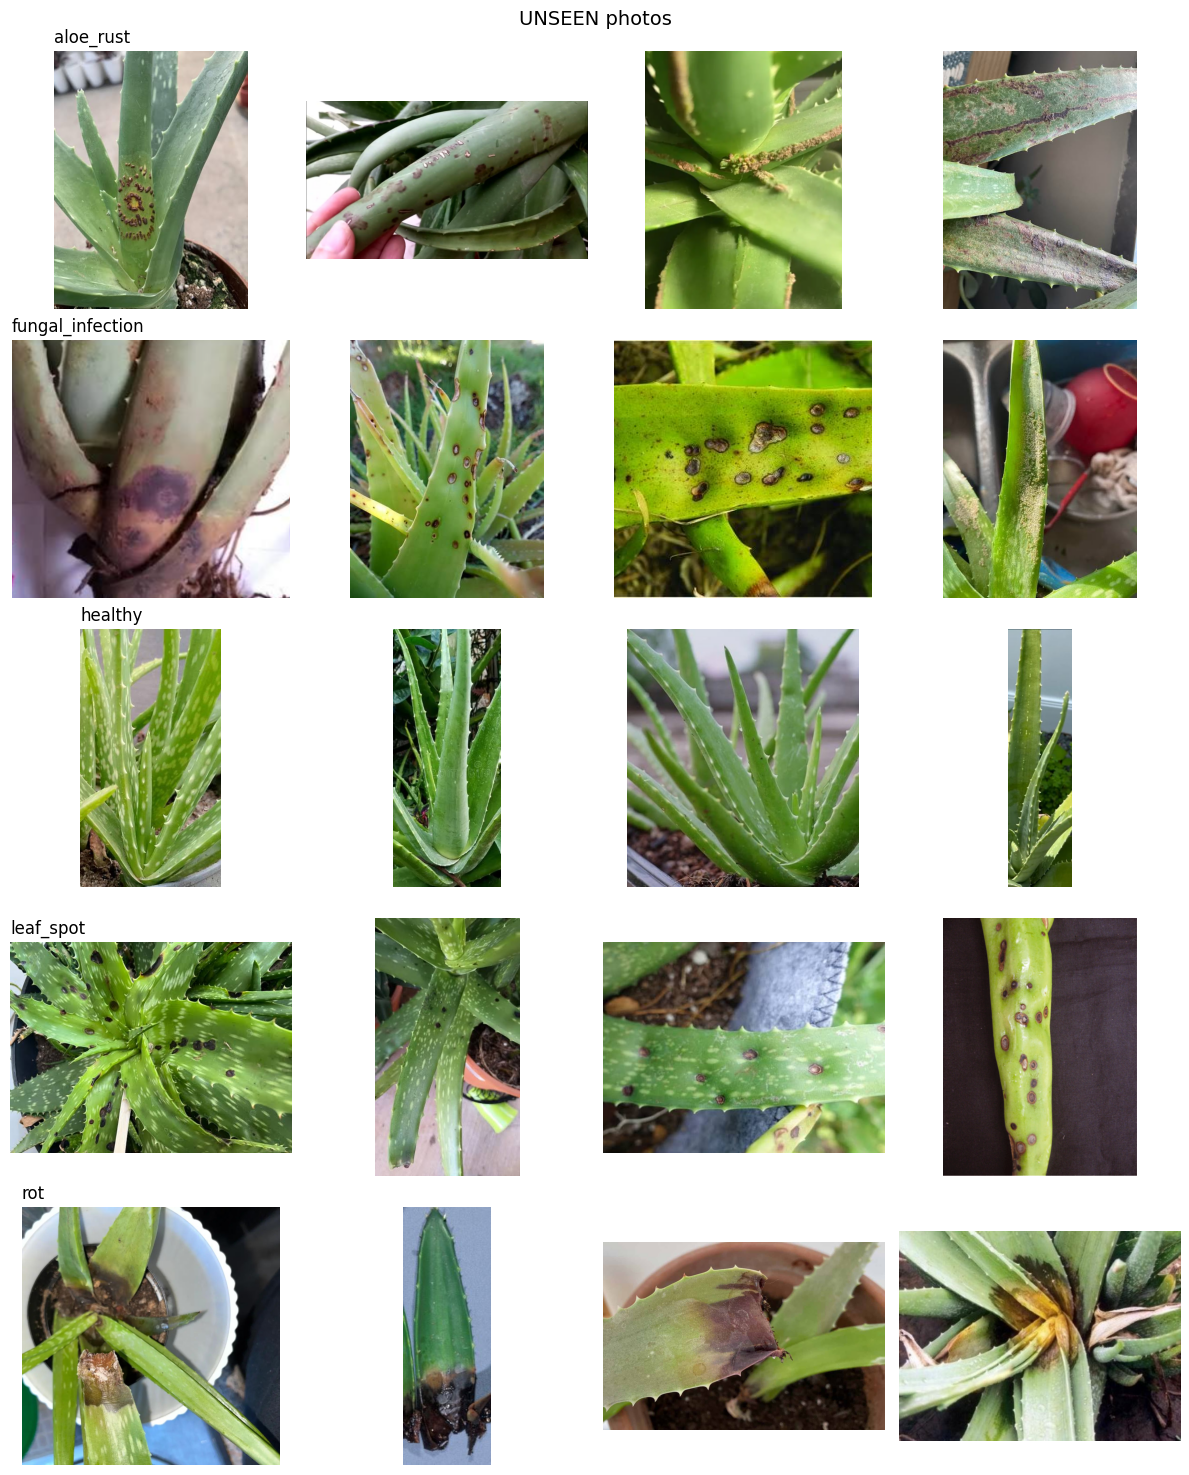

In [7]:
def show_samples(paths, labels, title, n=4, max_classes=8):
    cls = sorted(set(labels))[:max_classes]
    fig, axes = plt.subplots(len(cls), n, figsize=(3 * n, 3 * len(cls)), squeeze=False)
    rng = random.Random(1)
    for ax in axes.ravel():
        ax.axis("off")
    for r, c in enumerate(cls):
        pool = [p for p, l in zip(paths, labels) if l == c]
        for k, p in enumerate(rng.sample(pool, min(n, len(pool)))):
            axes[r][k].imshow(Image.open(p).convert("RGB"))
            if k == 0:
                axes[r][k].set_title(c, loc="left", fontsize=12)
    fig.suptitle(title, fontsize=14)
    plt.tight_layout(); plt.show()

show_samples(un_paths, un_labels, "UNSEEN photos")
if TRAIN_DIR:
    _p, _l = list_images(TRAIN_DIR)
    show_samples(_p, _l, "TRAINING photos (for comparison)")


===== UNSEEN photos: accuracy 30.99% | macro F1 0.224 =====

                  precision    recall  f1-score   support

       aloe_rust      0.326     0.933     0.483        15
fungal_infection      0.000     0.000     0.000        15
         healthy      1.000     0.062     0.118        16
       leaf_spot      0.316     0.400     0.353        15
             rot      0.500     0.100     0.167        10

        accuracy                          0.310        71
       macro avg      0.428     0.299     0.224        71
    weighted avg      0.431     0.310     0.227        71

How often each class really occurs vs how often the model predicts it
(one class predicted far more than it occurs = the model is falling back on it):
  aloe_rust                 true   15 | predicted   43
  fungal_infection          true   15 | predicted    6
  healthy                   true   16 | predicted    1
  leaf_spot                 true   15 | predicted   19
  rot                       true   10 | pr

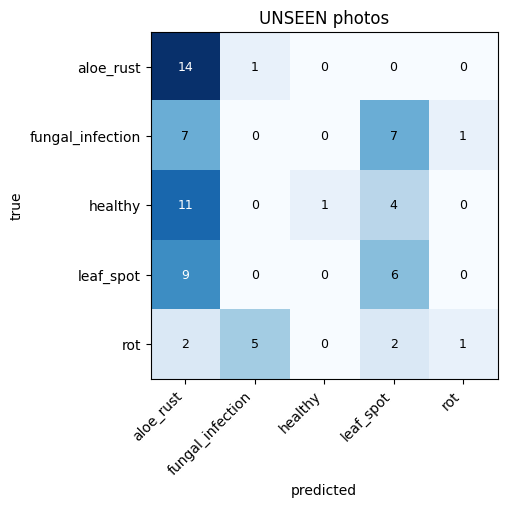


Healthy vs diseased accuracy: 78.87%
'diseased' photos called HEALTHY: 0 of 55
'healthy' photos called DISEASED: 15 of 16
(Always answering 'diseased' would score 77.5%)

Average confidence: 97% when right | 86% when wrong

Per photo (wrong ones only):
✗  Rust2.jpg                                true=aloe_rust          pred=fungal_infection   (100%)
✗  Fungal1.jpg                              true=fungal_infection   pred=leaf_spot          (64%)
✗  Fungal10.jpg                             true=fungal_infection   pred=aloe_rust          (96%)
✗  Fungal11.jpg                             true=fungal_infection   pred=leaf_spot          (57%)
✗  Fungal12.jpg                             true=fungal_infection   pred=leaf_spot          (100%)
✗  Fungal13.png                             true=fungal_infection   pred=aloe_rust          (91%)
✗  Fungal14.png                             true=fungal_infection   pred=rot                (66%)
✗  Fungal15.png                             true=fungal_in

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

def load_img(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(tf.round(tf.clip_by_value(img, 0, 255)), tf.uint8)   # uint8 keeps the cache small
    return img, label

def to_float(img, label):
    return tf.cast(img, tf.float32), label

def plot_cm(cm, title):
    size = max(4.6, 0.65 * K + 2.5)
    fig, ax = plt.subplots(figsize=(size, size * 0.9))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(IDX); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(IDX); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in IDX:
        for j in IDX:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout(); plt.show()

def binary_check(y, pred):
    if POS_CLASS not in class_to_idx:
        return
    a, b = POS_NAMES
    g = class_to_idx[POS_CLASS]
    t, p = (y == g), (pred == g)
    print(f"\n{a.capitalize()} vs {b} accuracy: {(t == p).mean() * 100:.2f}%")
    print(f"'{b}' photos called {a.upper()}: {int(((~t) & p).sum())} of {int((~t).sum())}")
    print(f"'{a}' photos called {b.upper()}: {int((t & ~p).sum())} of {int(t.sum())}")
    print(f"(Always answering '{b}' would score {(~t).mean() * 100:.1f}%)")

def report(y, pred, name):
    """Accuracy, per-class report, how often each class is predicted, main mix-ups, confusion matrix."""
    acc = accuracy_score(y, pred)
    f1 = f1_score(y, pred, average="macro", labels=sorted(set(y)), zero_division=0)
    print(f"\n===== {name}: accuracy {acc * 100:.2f}% | macro F1 {f1:.3f} =====\n")
    print(classification_report(y, pred, labels=IDX, target_names=CLASSES, digits=3, zero_division=0))
    print("How often each class really occurs vs how often the model predicts it")
    print("(one class predicted far more than it occurs = the model is falling back on it):")
    for i, c in enumerate(CLASSES):
        print(f"  {c:25s} true {int((y == i).sum()):4d} | predicted {int((pred == i).sum()):4d}")
    cm = confusion_matrix(y, pred, labels=IDX)
    pairs = sorted(((cm[i, j], CLASSES[i], CLASSES[j]) for i in IDX for j in IDX if i != j and cm[i, j] > 0), reverse=True)[:8]
    if pairs:
        print("\nMost common mix-ups (count: true -> predicted):")
        for n, a, b in pairs:
            print(f"  {n:4d}: {a} -> {b}")
    print("\nconfusion matrix (rows = true, columns = predicted):", CLASSES)
    print(cm)
    plot_cm(cm, name)
    binary_check(y, pred)
    return acc, f1

def make_ds(paths, labels):
    y = np.array([class_to_idx[l] for l in labels], dtype=np.int32)
    ds = tf.data.Dataset.from_tensor_slices((np.array(paths), y))
    ds = ds.map(load_img, num_parallel_calls=AUTOTUNE).map(to_float, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

probs_u = model.predict(make_ds(un_paths, un_labels), verbose=0)
pred_u = probs_u.argmax(1)
unseen_acc, unseen_f1 = report(y_u, pred_u, "UNSEEN photos")

conf = probs_u.max(1)
print(f"\nAverage confidence: {conf[pred_u == y_u].mean() * 100:.0f}% when right"
      + (f" | {conf[pred_u != y_u].mean() * 100:.0f}% when wrong" if (pred_u != y_u).any() else ""))

print(f"\nPer photo ({'all' if len(y_u) <= 60 else 'wrong ones only'}):")
for p, t, pr, pb in zip(un_paths, y_u, pred_u, conf):
    if len(y_u) <= 60 or t != pr:
        print(f"{'✓' if t == pr else '✗'}  {Path(p).name[:40]:40s} true={CLASSES[t]:18s} pred={CLASSES[pr]:18s} ({pb * 100:.0f}%)")

# save every prediction to a CSV (useful for the report)
df = pd.DataFrame({"file": [Path(p).name for p in un_paths], "true": [CLASSES[i] for i in y_u],
                   "predicted": [CLASSES[i] for i in pred_u], "correct": pred_u == y_u, "confidence": conf.round(3)})
for i, c in enumerate(CLASSES):
    df[f"p_{c}"] = probs_u[:, i].round(3)
csv_path = f"{OUT_DIR}/{PREFIX}_unseen_predictions.csv"
df.to_csv(csv_path, index=False)
print("\nsaved:", csv_path)

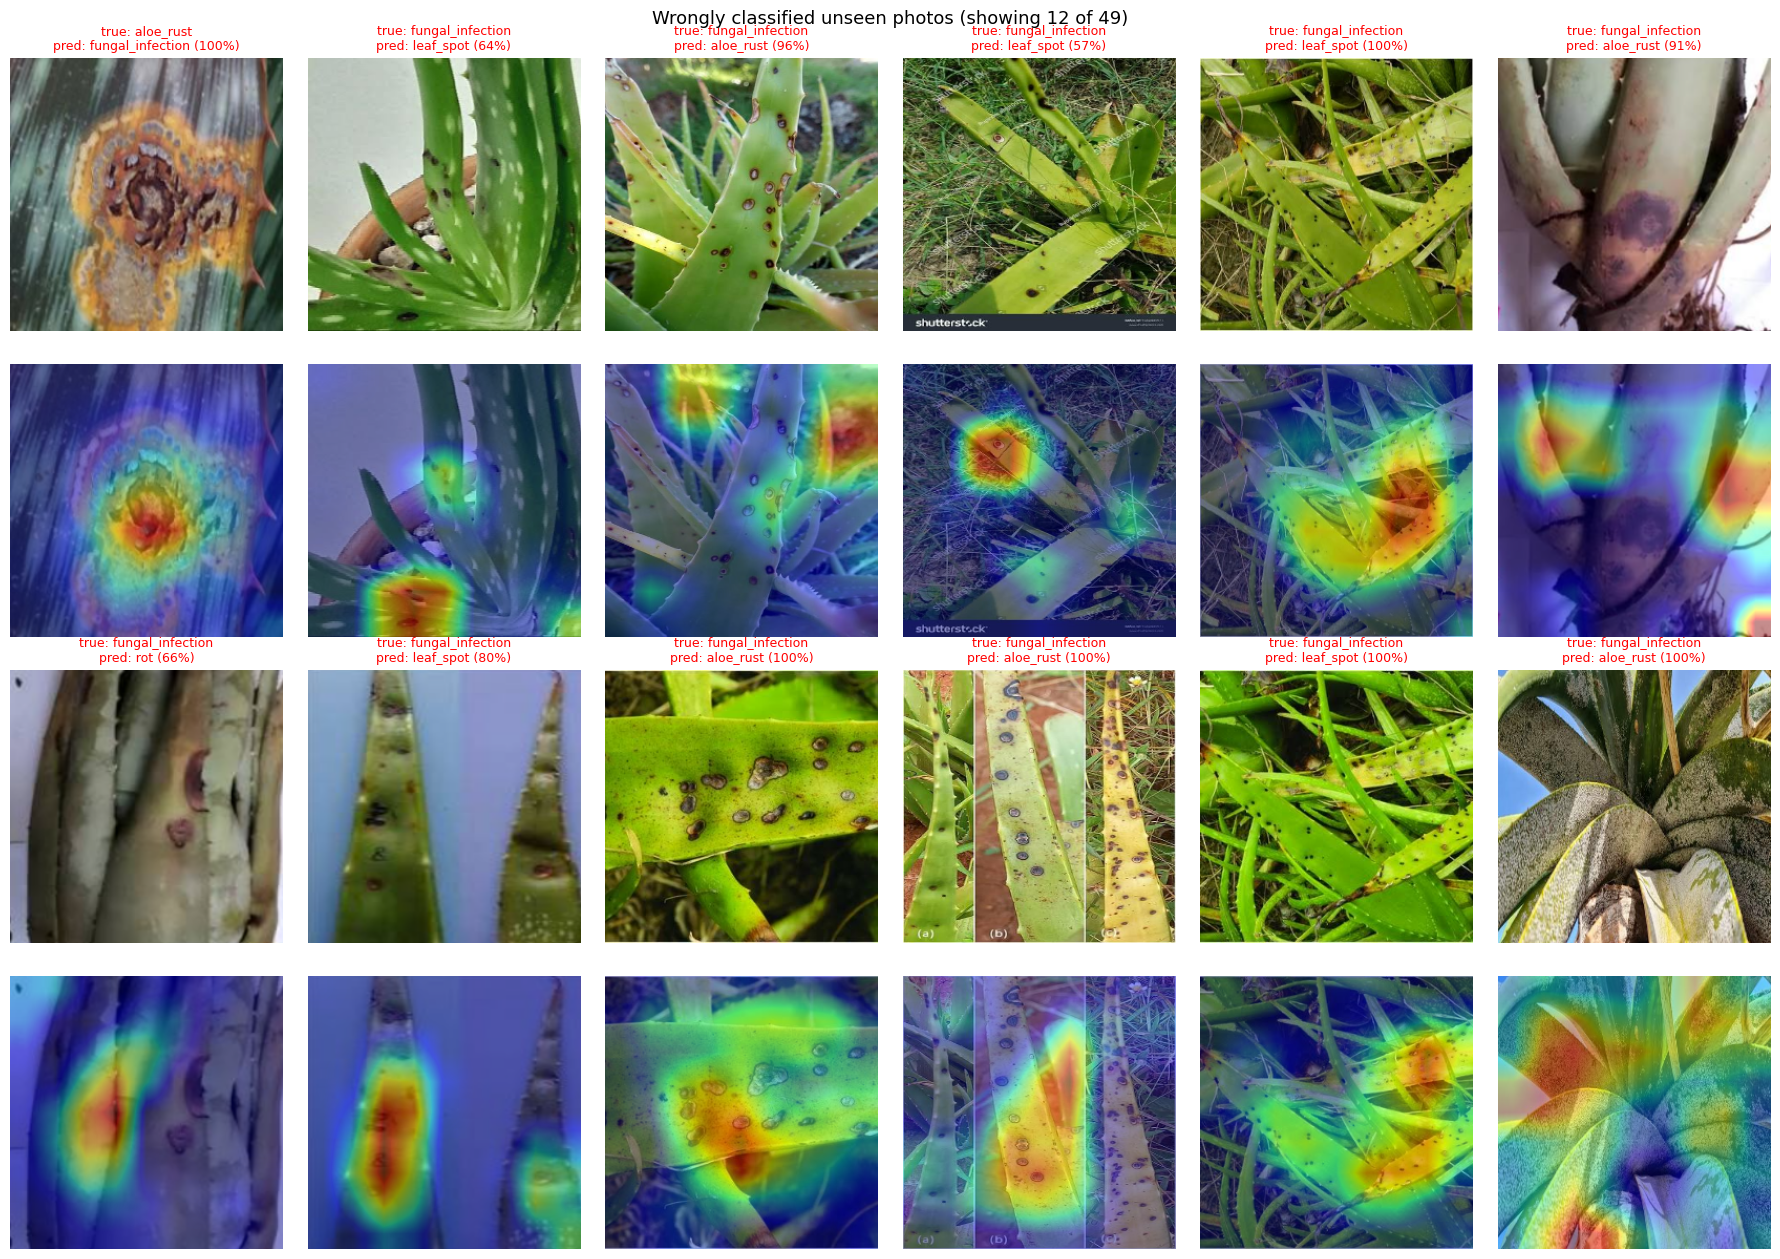

In [9]:
wrong = [i for i in range(len(un_paths)) if y_u[i] != pred_u[i]]
if not wrong:
    print("No wrong predictions.")
else:
    try:
        base = next(l for l in model.layers if isinstance(l, keras.Model))     # the nested EfficientNet
        conv_model = keras.Model(base.inputs, base.output)
        head_dense = model.layers[-1]

        def gradcam(x):
            x = tf.convert_to_tensor(x[None], dtype=tf.float32)
            with tf.GradientTape() as tape:
                conv = conv_model(x, training=False)
                probs = head_dense(tf.reduce_mean(conv, axis=(1, 2)))
                cls = int(tf.argmax(probs[0]))
                score = probs[:, cls]
            grads = tape.gradient(score, conv)
            w = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
            cam = tf.nn.relu(tf.reduce_sum(w * conv, axis=-1))[0]
            cam = cam / (tf.reduce_max(cam) + 1e-8)
            return tf.image.resize(cam[..., None], (IMG_SIZE, IMG_SIZE))[..., 0].numpy(), cls

        show = wrong[:12]
        cols = min(6, len(show)); rows = math.ceil(len(show) / cols)
        fig, axes = plt.subplots(rows * 2, cols, figsize=(3 * cols, 6.4 * rows), squeeze=False)
        for ax in axes.ravel(): ax.axis("off")
        for k, i in enumerate(show):
            r, c = (k // cols) * 2, k % cols
            arr = load_img(un_paths[i], 0)[0].numpy().astype("float32")
            cam, cls = gradcam(arr)
            axes[r][c].imshow(arr.astype("uint8"))
            axes[r][c].set_title(f"true: {CLASSES[y_u[i]]}\npred: {CLASSES[cls]} ({conf[i] * 100:.0f}%)", fontsize=9, color="red")
            axes[r + 1][c].imshow(arr.astype("uint8")); axes[r + 1][c].imshow(cam, cmap="jet", alpha=0.45)
        fig.suptitle(f"Wrongly classified unseen photos (showing {len(show)} of {len(wrong)})", fontsize=13)
        plt.tight_layout(); plt.show()
    except Exception as e:
        print("Grad-CAM could not be drawn for this model:", repr(e))
        cols = min(6, len(wrong)); rows = math.ceil(len(wrong) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3.2 * rows), squeeze=False)
        for ax in axes.ravel(): ax.axis("off")
        for k, i in enumerate(wrong):
            ax = axes[k // cols][k % cols]
            ax.imshow(Image.open(un_paths[i]).convert("RGB"))
            ax.set_title(f"true {CLASSES[y_u[i]]}\npred {CLASSES[pred_u[i]]}", fontsize=10, color="red")
        plt.tight_layout(); plt.show()

In [10]:
print("================ SUMMARY (unseen photos) ================")
print(f"model    : {Path(MODEL_PATH).name}")
print(f"photos   : {len(un_paths)}")
print(f"accuracy : {unseen_acc * 100:.2f}%")
print(f"macro F1 : {unseen_f1:.3f}")
try:
    print(f"baseline : {baseline_acc * 100:.2f}% (colour statistics + random forest)")
except Exception:
    pass

================ SUMMARY (unseen photos) ================
model    : disease_efficientnetb2.keras
photos   : 71
accuracy : 30.99%
macro F1 : 0.224
